# Problem Set 2: Risk Measures with Stochastic Volatility Models

## Introduction

In this problem set you will implement and compare two approaches for estimating
financial risk measures:

1. **Kalman Filter + Maximum Likelihood Estimation (MLE)**
2. **EGARCH model** (Part 2)

Using these methods you will compute:
- **Value-at-Risk (VaR)**
- **Expected Shortfall (ES)**

## Learning Objectives
- Implement a Kalman Filter for stochastic volatility models
- Apply MLE to estimate model parameters
- Compare Kalman Filter and EGARCH volatility estimates
- Implement and interpret VaR and ES
- Evaluate model calibration with the coverage ratio

---
**Total: 9 points.  This notebook covers Tasks 1 and 2 (4 pts).**


> **Submission filename:** Rename this notebook to `submission_1_fullname.ipynb`
> (replace `fullname` with your actual name, e.g. `submission_1_Jane_Doe.ipynb`).
> Submit it together with Part 2 (`submission_2_fullname.ipynb`) and your PDF report.


> **Submission Rules:**
> - Do **not** include `%pip install`, `!pip install`, or any package-installation commands.
>   The grading environment has all required packages pre-installed.
> - Do **not** import libraries beyond `numpy`, `scipy`, `matplotlib`, and `arch`.
>   Submissions that import unavailable packages will **receive a score of 0**.


In [7]:
# Required libraries — do NOT add pip install commands or other packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm          # normal distribution (for VaR/ES in Part 2)
from scipy.optimize import minimize   # numerical optimisation (MLE in Part 2)
from arch import arch_model           # EGARCH model (Part 2)


## Part 1 — Simulate Data from a Stochastic Volatility (SV) Model

We start by generating simulated data so we can evaluate our estimation methods
against **known** ("ground-truth") parameters.

### Task 1.0 — Model Specification *(written answer, 0 pts – conceptual)*

Write down the data-generating process (DGP) for the SV model using lecture notation.
Define every symbol.

### Task 1.1 — Simulate SV Data *(2 pts)*

Simulate from the SV model with:

| Setting | Value |
|---------|-------|
| Seed | `np.random.seed(1234)` |
| Sample size | T = 2 500 |
| Volatility persistence | φ = 0.95 |
| Vol-of-vol | σ_η = 0.2 |
| Unconditional volatility | σ = 1.0 |
| Initial log-vol | draw from its unconditional distribution |

Then apply the **Harvey transform**: `y_t = log(r_t²)` to linearise the model.

---
**Autograder checks (Task 1, 2 pts):**

| Variable | Requirement |
|----------|-------------|
| `h` or `h_true` | log-volatility array, length 2500 |
| `r` | returns array, length 2500 |
| `y` | Harvey-transformed series `log(r**2)`, length 2500 |
| Seed | `np.random.seed(1234)` before any random call |
| Parameters | `phi=0.95`, `sigma_eta=0.2`, `sigma=1.0` |
| Init | `h[0]` drawn from unconditional distribution of h |
| Loop | AR(1) recursion for h |
| Returns | `r_t = sigma * exp(0.5 * h_t) * xi_t` |


In [8]:
# Task 1.0 — Written Answer
# Write your DGP specification below as comments.
#
# The stochastic volatility model:
#
#   Observation equation:  r_t = sigma * exp(0.5 * h_t) * eps_t
#   State equation:        h_t = phi * h_{t-1} + eta_t  (hidden state)
#
# Symbol definitions:
#   r_t       = observed return at time t
#   h_t       = latent log-volatility at time t
#   phi       = persistence parameter of the volatility process
#   sigma_eta = standard deviation of the volatility innovation
#   sigma     = scale parameter of returns
#   eps_t     = observation innovation, eps_t ~ N(0,1)
#   eta_t     = state innovation, eta_t ~ N(0, sigma_eta^2)


In [9]:
# Task 1.1 — Simulate SV Data
# ─────────────────────────────────────────────────────────────────────────────

# Set the random seed FIRST (required by the autograder — do not move this line)
np.random.seed(1234)

# --- Given parameters (do not change) ---
T         = 2500
phi       = 0.95
sigma_eta = 0.2
sigma     = 1.0

# --- Allocate the log-volatility array ---
h = np.zeros(T)

# --- STEP 1: Initialise h[0] from its unconditional distribution ---
# Hint: the unconditional standard deviation of h is  sigma_eta / sqrt(1 - phi^2)
# TODO: draw h[0] from N(0, sigma_eta / sqrt(1 - phi^2))
h[0] = np.random.normal(0, sigma_eta / np.sqrt(1 - phi**2))

# --- STEP 2: Simulate the log-volatility path (AR(1) recursion) ---
for t in range(1, T):
    # TODO: h[t] = phi * h[t-1] + a N(0, sigma_eta) shock
    h[t] = phi * h[t - 1] + np.random.normal(0, sigma_eta)

# --- STEP 3: Simulate returns ---
# Hint: draw T independent N(0,1) shocks (xi), then r_t 
# TODO: xi = ...
xi = np.random.normal(0, 1, T)
# TODO: r = ...
r  = sigma * np.exp(0.5 * h) * xi # buraya tekrar bak!!!!!

# --- STEP 4: Apply the Harvey transform  y_t  ---
# (This linearises the SV model so the Kalman filter can be applied)
# TODO: y = ...
y = np.log(r**2)

print(f"Simulated {T} observations.")
print(f"Mean of h (expect ≈ 0): {h.mean():.4f}")
print(f"Mean of r (expect ≈ 0): {r.mean():.4f}")


Simulated 2500 observations.
Mean of h (expect ≈ 0): 0.1415
Mean of r (expect ≈ 0): 0.0229


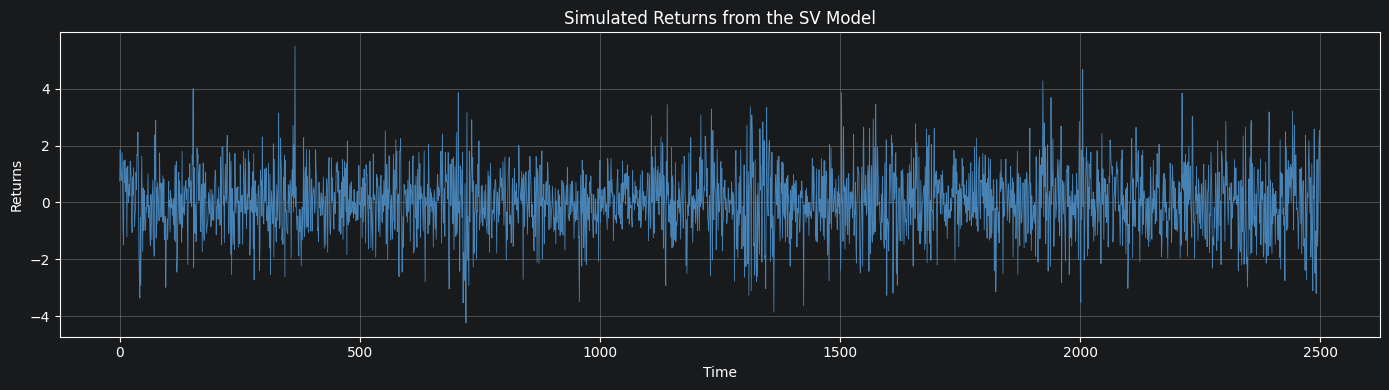

In [10]:
# Plot the simulated return series
plt.figure(figsize=(14, 4))
plt.plot(r, linewidth=0.6, color='steelblue')
plt.title('Simulated Returns from the SV Model')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.grid(True)
plt.tight_layout()
plt.show()


## Part 2 — Kalman Filter Implementation

To estimate the SV model we first linearise it with the **Harvey transform**,
giving a linear state-space model that the Kalman filter can handle.

### Task 2.0 — The Harvey Transform *(written answer, 0 pts – conceptual)*

Explain step-by-step how the Harvey transform linearises the SV model.
State the transformed DGP (observation + state equations, noise distributions).

### Task 2.1 — Implement the Kalman Filter *(2 pts)*

Implement the Kalman filter using the notation from lecture.

**Function signature** (do not rename):
```python
def kalman_filter(y, a, B, Phi, H, Q, a1, P1, return_loglike=False):
```

**Kalman filter recursion** (for t = 0, 1, …, T−1):

| Step | Formula |
|------|---------|
| Innovation variance | F_t = B² · P_prior[t] + H |
| Innovation | v_t = y[t] − (a + B · a_prior[t]) |
| Log-likelihood contribution | −½ · (log(2π) + log(F_t) + v_t²/F_t) |
| Kalman gain | K_t = P_prior[t] · B / F_t |
| Posterior mean | a_post[t] = a_prior[t] + K_t · v_t |
| Posterior variance | P_post[t] = P_prior[t] · (1 − K_t · B) |
| Next prior mean | a_prior[t+1] = Phi · a_post[t] |
| Next prior variance | P_prior[t+1] = Phi² · P_post[t] + Q |

---
**Autograder checks (Task 2, 2 pts):**

| Check | Requirement |
|-------|-------------|
| Function name | exactly `kalman_filter` |
| `return_loglike=True` | returns a **positive** scalar NLL |
| `return_loglike=False` | returns **(a_post, P_post, a_prior, P_prior)** — 4 arrays of length T |
| P_post values | all strictly > 0 |
| NLL accuracy | within 1 % of reference |
| Correlation of a_post with true h | > 0.4 |


In [11]:
# Task 2.0 — Written Answer
# Explain the Harvey transform step-by-step as comments below.
#
# Step 1: Square the returns to remove the sign:
#   r_t^2 = sigma**2 * exp(h_t) * eps_t**2
#
# Step 2: Take the log to linearise:
#   y_t = log(r_t^2) = 2*log(sigma) + h_t + 2*log(eps_t)
#
# The transformed model becomes a LINEAR state-space model:
#
#   Observation equation:  y_t = a + B * h_t + epsilon_t
#     a   = 2*log(sigma) - 1.2704    (hint: involves E[log(chi^2_1)] = -1.2704)
#     B   = 1
#     Var(epsilon_t) = H = pi**2/2   (hint: Var[log(chi^2_1)] = pi^2/2)
#
#   State equation:        h_t = Phi * h_{t-1} + eta_t
#     Phi = phi
#     Var(eta_t) = Q = sigma_eta**2


In [12]:
# Task 2.1 — Implement the Kalman Filter
# ─────────────────────────────────────────────────────────────────────────────

def kalman_filter(y, a, B, Phi, H, Q, a1, P1, return_loglike=False):
    """
    Kalman filter for the Harvey-transformed SV model.

    Parameters
    ----------
    y            : array (T,)  — Harvey-transformed returns  log(r^2)
    a            : float       — constant in observation equation
    B            : float       — observation loading  (= 1 for SV)
    Phi          : float       — state transition coefficient  (= phi)
    H            : float       — observation noise variance  (= pi^2/2)
    Q            : float       — state noise variance  (= sigma_eta^2)
    a1           : float       — initial prior mean of h
    P1           : float       — initial prior variance of h
    return_loglike : bool      — True  → return scalar NLL (positive)
                                 False → return (a_post, P_post, a_prior, P_prior)
    """
    T = len(y)

    # --- Allocate storage (do not rename these arrays) ---
    a_prior = np.zeros(T)   # prior mean     E[h_t | y_1,...,y_{t-1}]
    P_prior = np.zeros(T)   # prior variance
    a_post  = np.zeros(T)   # posterior mean E[h_t | y_1,...,y_t]
    P_post  = np.zeros(T)   # posterior variance

    # --- Initial prior (given) ---
    a_prior[0] = a1
    P_prior[0] = P1

    log_like = 0.0

    for t in range(T):

        # 1. Innovation variance:  F_t 
        # TODO:
        F_t = B**2 * P_prior[t] + H

        # 2. Innovation (prediction error):  v_t 
        # TODO:
        v_t = y[t] - (a + B * a_prior[t])

        # 3. Log-likelihood contribution:  
        # TODO:
        log_like +=  -0.5 * (np.log(2*np.pi) + np.log(F_t) + v_t**2 / F_t)

        # 4. Kalman gain:  K_t 
        # TODO:
        K_t = P_prior[t] * B / F_t

        # 5. Posterior mean:  a_post[t]
        # TODO:
        a_post[t] = a_prior[t] + K_t * v_t

        # 6. Posterior variance:  P_post[t] 
        # TODO:
        P_post[t] = P_prior[t] * (1 - K_t * B)

        # 7. Predict next step
        if t < T - 1:
            # Prior mean:      a_prior[t+1] 
            # TODO:
            a_prior[t + 1] = Phi * a_post[t]
            # Prior variance:  P_prior[t+1] 
            # TODO:
            P_prior[t + 1] = Phi**2 * P_post[t] + Q

    if return_loglike:
        return -log_like   # return NEGATIVE log-likelihood (must be a positive scalar)
    return a_post, P_post, a_prior, P_prior


# Quick sanity check (should print a positive number once implemented)
print(kalman_filter(y, -1.2704+np.log(1.0**2), 1.0, 0.95, np.pi**2/2, 0.2**2, 0.0, 0.2**2/(1-0.95**2), return_loglike=True))


5536.872047408669
